## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

### Plot Style 

In [2]:
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.family": "DejaVu Sans"
})

In [3]:
df = pd.read_csv("Sample - Superstore.csv", encoding="windows-1252")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst look:")
df.head()

Shape: (9994, 21)

Columns:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First look:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Inspection 

In [4]:
print("="*50)
print("SHAPE:", df.shape)
print("="*50)

print("\nDATA TYPES:")
print(df.dtypes)

print("\nMISSING VALUES:")
print(df.isnull().sum())

print("\nDUPLICATE ROWS:", df.duplicated().sum())

print("\nBASIC STATISTICS:")
df.describe()

SHAPE: (9994, 21)

DATA TYPES:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

MISSING VALUES:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64



,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# Data Cleaning & Feature Engineering

In [5]:
# ─── FIX DATE COLUMNS ──────────────────────────────────────────────────────
df["Order Date"]  = pd.to_datetime(df["Order Date"])
df["Ship Date"]   = pd.to_datetime(df["Ship Date"])

In [6]:
# ─── EXTRACT TIME FEATURES ─────────────────────────────────────────────────
df["Order Year"]  = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = df["Order Date"].dt.strftime("%b")
df["Order Quarter"] = df["Order Date"].dt.quarter

In [7]:
# ─── SHIPPING DURATION ─────────────────────────────────────────────────────
df["Ship Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [8]:
# ─── PROFIT MARGIN ─────────────────────────────────────────────────────────
df["Profit Margin %"] = round((df["Profit"] / df["Sales"]) * 100, 2)

In [9]:
# ─── VERIFY ────────────────────────────────────────────────────────────────
print("Updated dtypes:")
print(df[["Order Date", "Ship Date", "Order Year", 
          "Order Month", "Ship Days", "Profit Margin %"]].dtypes)

Updated dtypes:
Order Date         datetime64[ns]
Ship Date          datetime64[ns]
Order Year                  int32
Order Month                 int32
Ship Days                   int64
Profit Margin %           float64
dtype: object


In [10]:
print("\nSample of new columns:")
df[["Order Date", "Order Year", "Order Month Name", 
    "Order Quarter", "Ship Days", "Profit Margin %"]].head(8)


Sample of new columns:


,Order Date,Order Year,Order Month Name,Order Quarter,Ship Days,Profit Margin %
0,2016-11-08,2016,Nov,4,3,16.00
1,2016-11-08,2016,Nov,4,3,30.00
2,2016-06-12,2016,Jun,2,4,47.00
3,2015-10-11,2015,Oct,4,7,-40.00
4,2015-10-11,2015,Oct,4,7,11.25
5,2014-06-09,2014,Jun,2,5,29.00
6,2014-06-09,2014,Jun,2,5,27.00
7,2014-06-09,2014,Jun,2,5,10.00


## Univariate Analysis

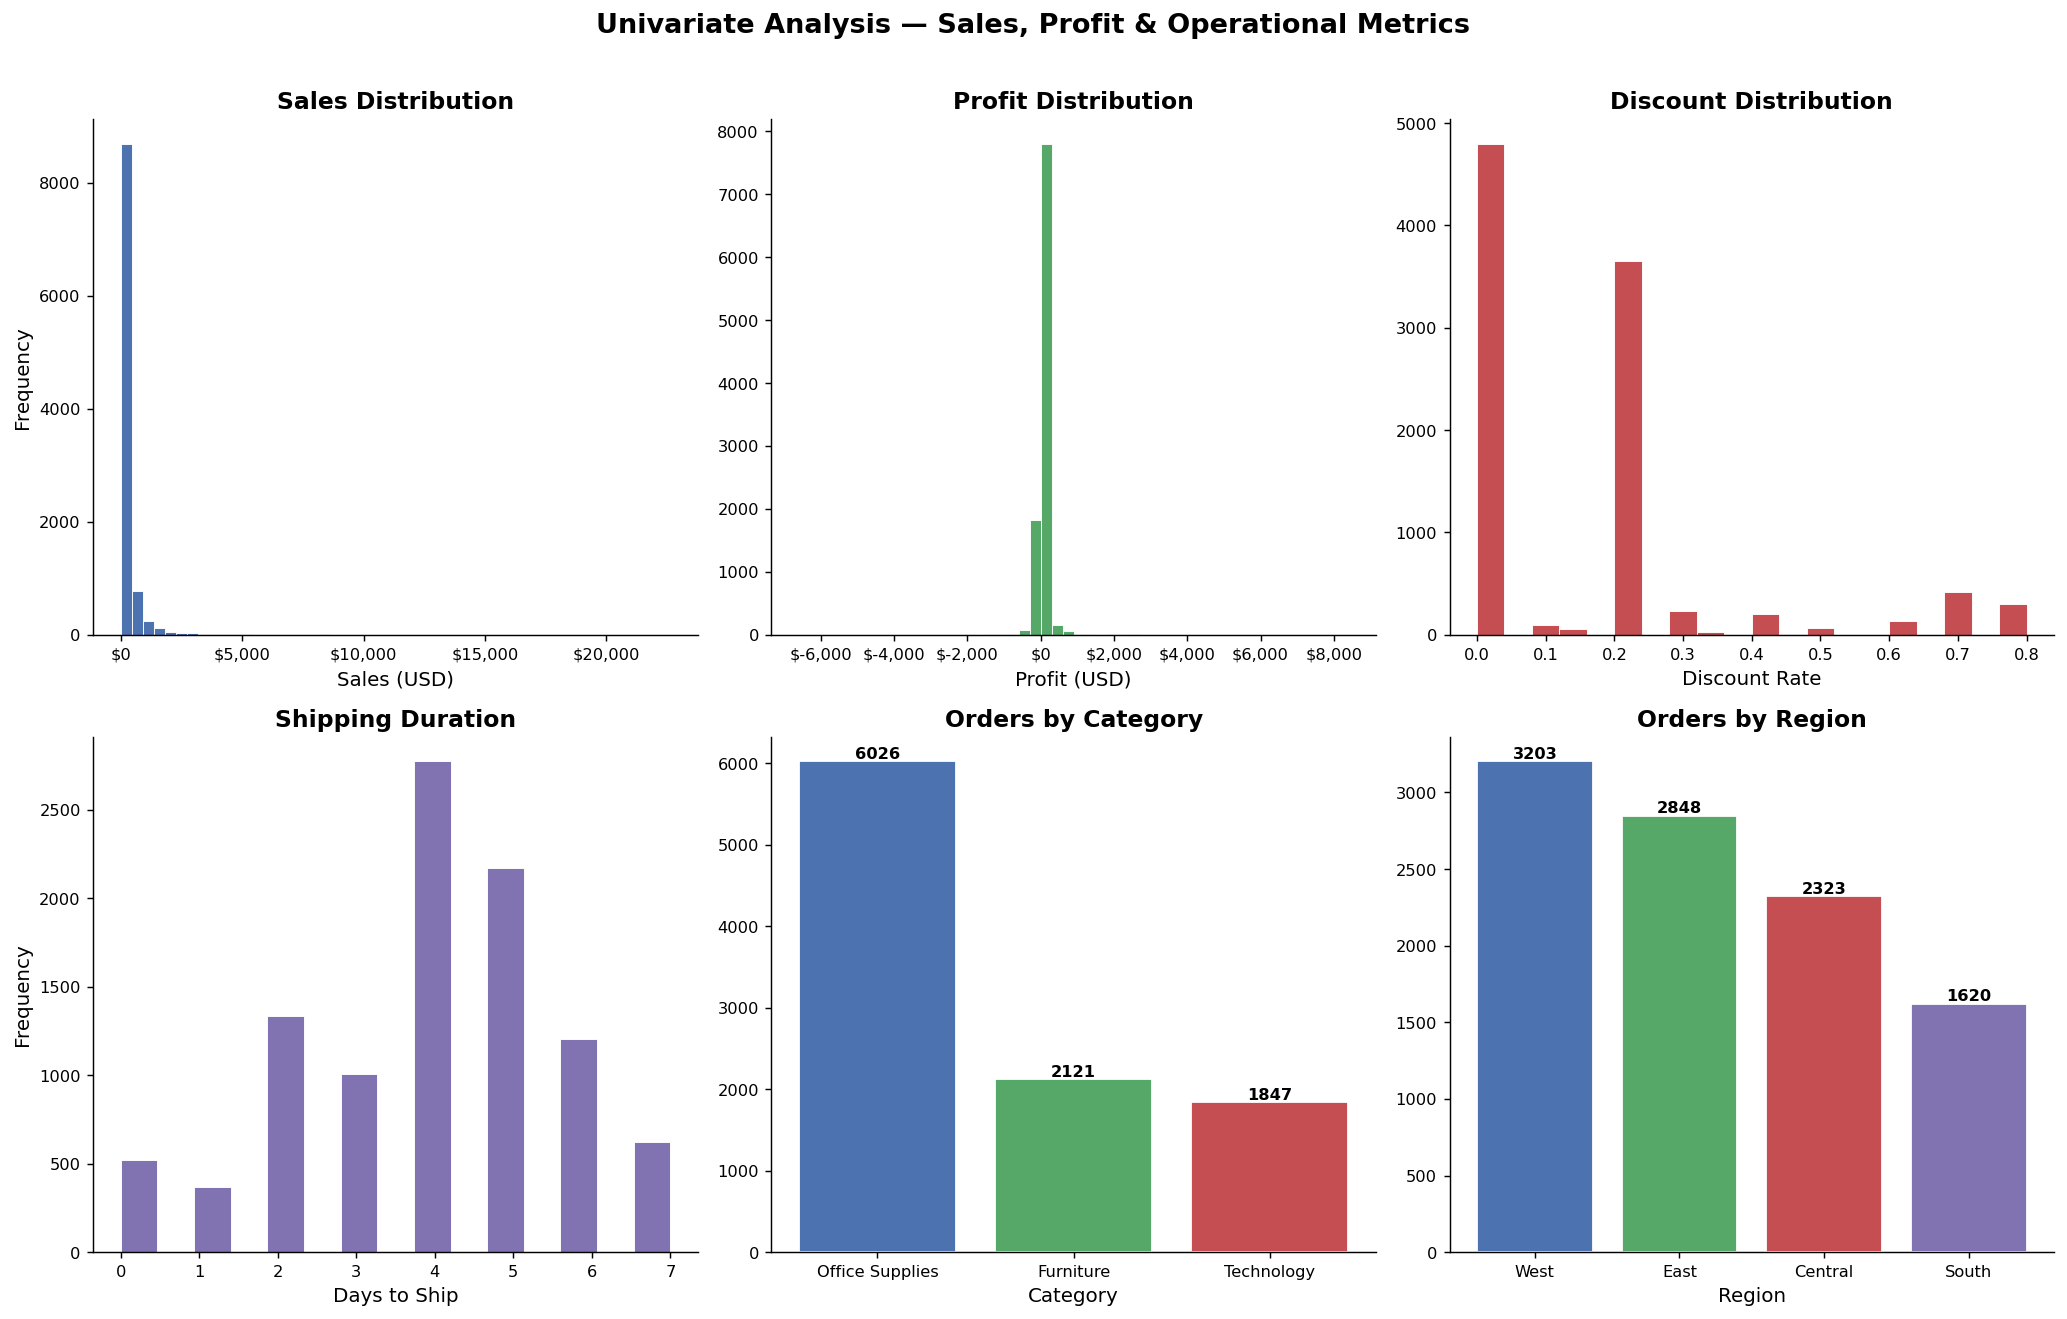

Saved: univariate_analysis.png


In [11]:
# ─── UNIVARIATE ANALYSIS ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Univariate Analysis — Sales, Profit & Operational Metrics", 
             fontsize=15, fontweight="bold", y=1.01)

# 1. Sales Distribution
axes[0,0].hist(df["Sales"], bins=50, color="#4C72B0", edgecolor="white", linewidth=0.5)
axes[0,0].set_title("Sales Distribution")
axes[0,0].set_xlabel("Sales (USD)")
axes[0,0].set_ylabel("Frequency")
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# 2. Profit Distribution
axes[0,1].hist(df["Profit"], bins=50, color="#55A868", edgecolor="white", linewidth=0.5)
axes[0,1].set_title("Profit Distribution")
axes[0,1].set_xlabel("Profit (USD)")
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# 3. Discount Distribution
axes[0,2].hist(df["Discount"], bins=20, color="#C44E52", edgecolor="white", linewidth=0.5)
axes[0,2].set_title("Discount Distribution")
axes[0,2].set_xlabel("Discount Rate")

# 4. Shipping Days Distribution
axes[1,0].hist(df["Ship Days"], bins=15, color="#8172B2", edgecolor="white", linewidth=0.5)
axes[1,0].set_title("Shipping Duration")
axes[1,0].set_xlabel("Days to Ship")
axes[1,0].set_ylabel("Frequency")

# 5. Orders by Category
category_counts = df["Category"].value_counts()
axes[1,1].bar(category_counts.index, category_counts.values,
              color=["#4C72B0","#55A868","#C44E52"], edgecolor="white")
axes[1,1].set_title("Orders by Category")
axes[1,1].set_xlabel("Category")
for i, v in enumerate(category_counts.values):
    axes[1,1].text(i, v + 30, str(v), ha="center", fontsize=9, fontweight="bold")

# 6. Orders by Region
region_counts = df["Region"].value_counts()
colors = ["#4C72B0","#55A868","#C44E52","#8172B2"]
axes[1,2].bar(region_counts.index, region_counts.values,
              color=colors, edgecolor="white")
axes[1,2].set_title("Orders by Region")
axes[1,2].set_xlabel("Region")
for i, v in enumerate(region_counts.values):
    axes[1,2].text(i, v + 20, str(v), ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("univariate_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: univariate_analysis.png")

## Bivariate Analysis

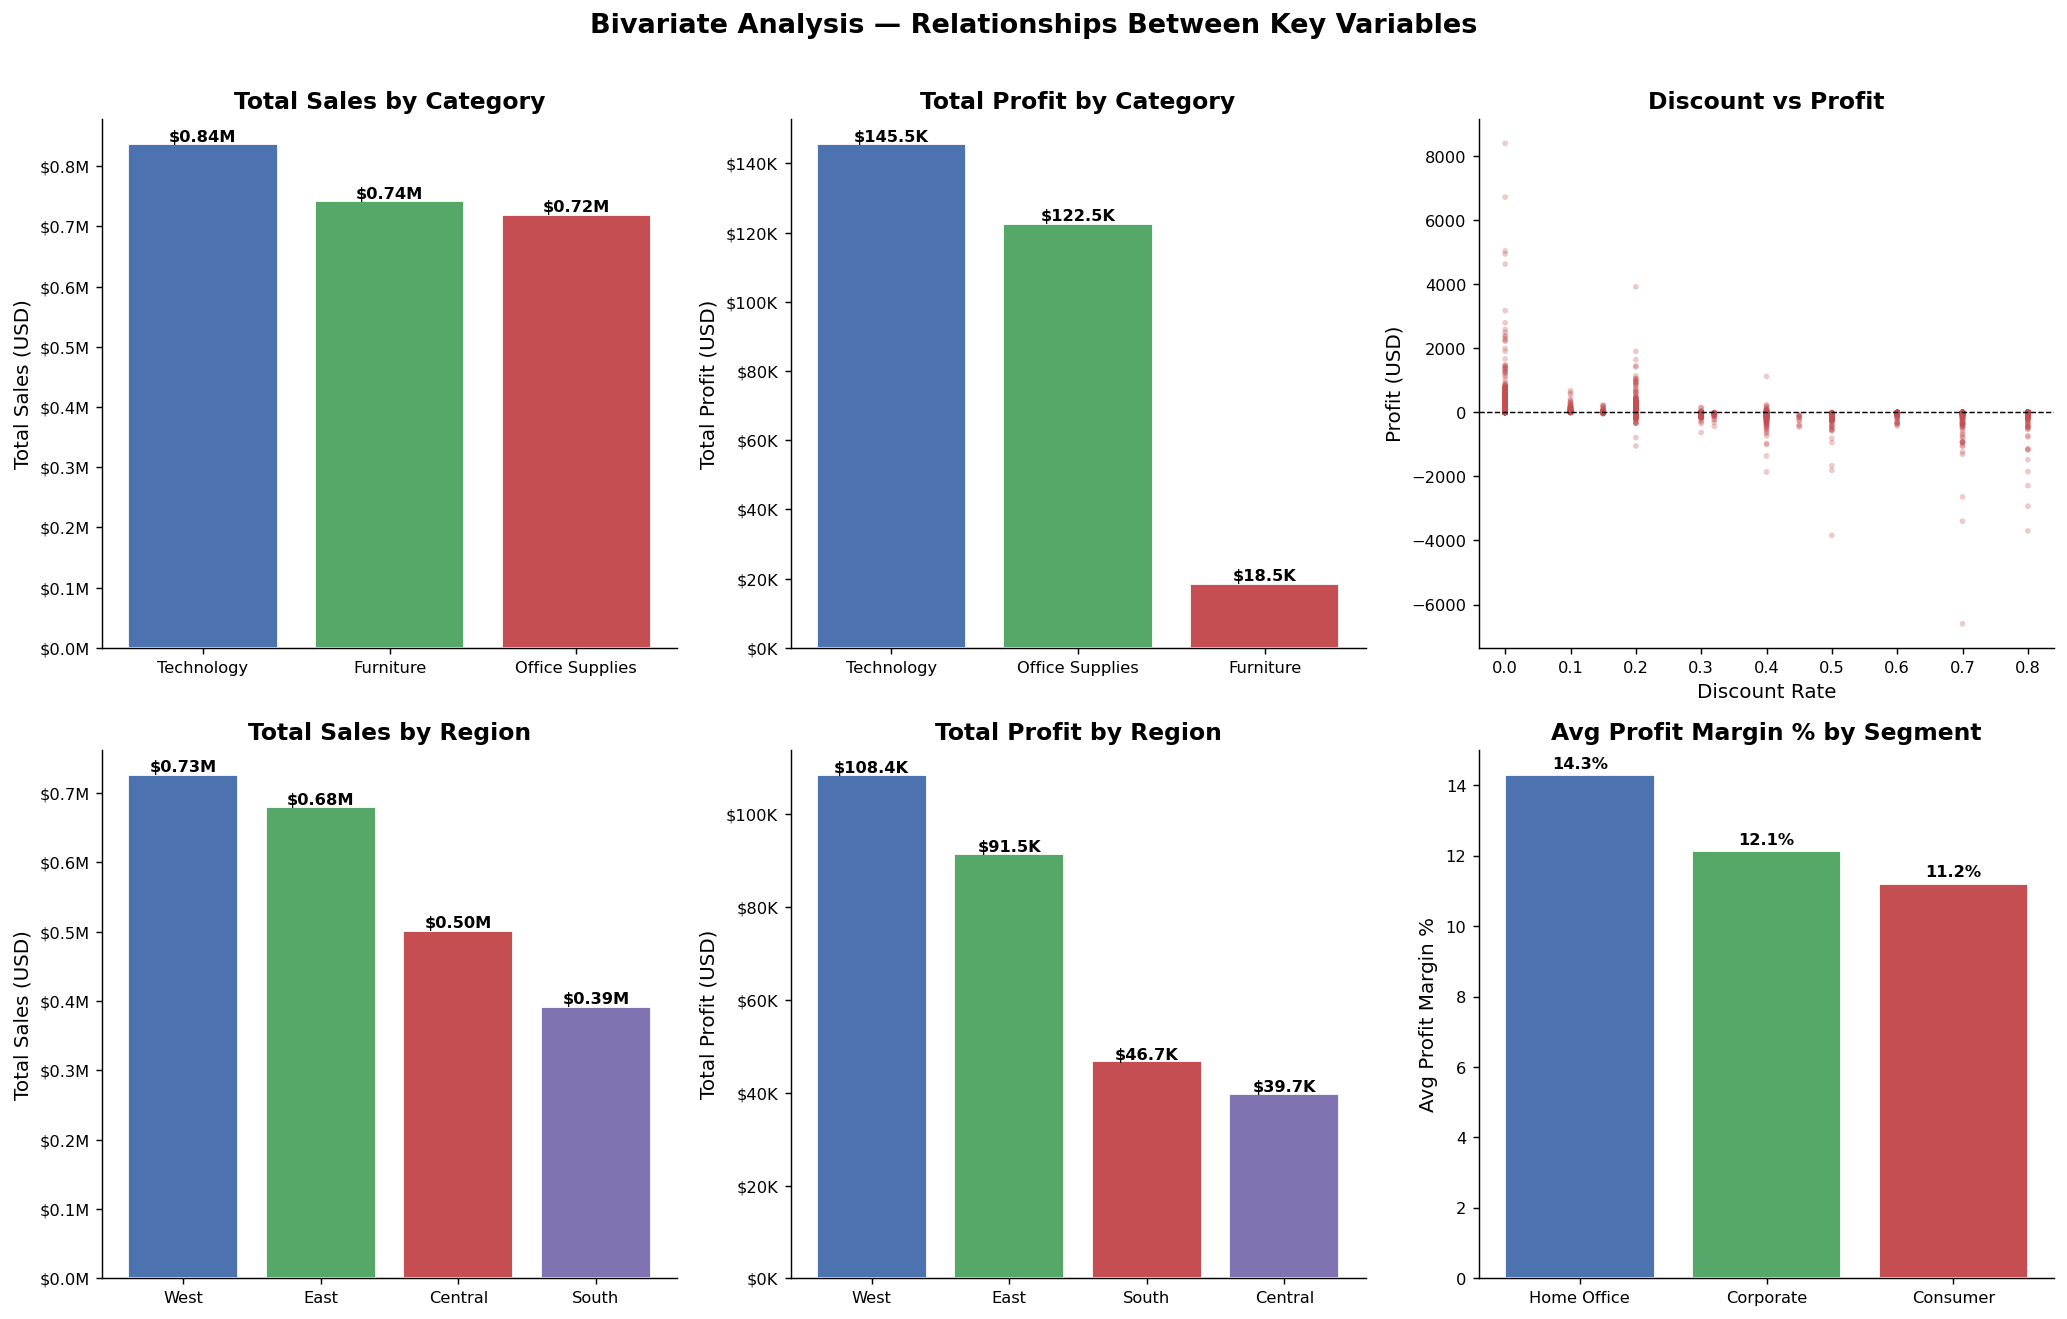

Saved: bivariate_analysis.png


In [13]:
# ─── BIVARIATE ANALYSIS ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Bivariate Analysis — Relationships Between Key Variables",
             fontsize=15, fontweight="bold", y=1.01)

# 1. Sales by Category
cat_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
bars = axes[0,0].bar(cat_sales.index, cat_sales.values,
                     color=["#4C72B0","#55A868","#C44E52"], edgecolor="white")
axes[0,0].set_title("Total Sales by Category")
axes[0,0].set_ylabel("Total Sales (USD)")
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
for bar, val in zip(bars, cat_sales.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                   f"${val/1e6:.2f}M", ha="center", fontsize=9, fontweight="bold")

# 2. Profit by Category
cat_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
bars2 = axes[0,1].bar(cat_profit.index, cat_profit.values,
                      color=["#4C72B0","#55A868","#C44E52"], edgecolor="white")
axes[0,1].set_title("Total Profit by Category")
axes[0,1].set_ylabel("Total Profit (USD)")
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
for bar, val in zip(bars2, cat_profit.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                   f"${val/1e3:.1f}K", ha="center", fontsize=9, fontweight="bold")

# 3. Discount vs Profit scatter
axes[0,2].scatter(df["Discount"], df["Profit"],
                  alpha=0.3, color="#C44E52", s=10, edgecolors="none")
axes[0,2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0,2].set_title("Discount vs Profit")
axes[0,2].set_xlabel("Discount Rate")
axes[0,2].set_ylabel("Profit (USD)")

# 4. Sales by Region
reg_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
axes[1,0].bar(reg_sales.index, reg_sales.values,
              color=["#4C72B0","#55A868","#C44E52","#8172B2"], edgecolor="white")
axes[1,0].set_title("Total Sales by Region")
axes[1,0].set_ylabel("Total Sales (USD)")
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
for i, (idx, val) in enumerate(reg_sales.items()):
    axes[1,0].text(i, val + 5000, f"${val/1e6:.2f}M",
                   ha="center", fontsize=9, fontweight="bold")

# 5. Profit by Region
reg_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
axes[1,1].bar(reg_profit.index, reg_profit.values,
              color=["#4C72B0","#55A868","#C44E52","#8172B2"], edgecolor="white")
axes[1,1].set_title("Total Profit by Region")
axes[1,1].set_ylabel("Total Profit (USD)")
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
for i, (idx, val) in enumerate(reg_profit.items()):
    axes[1,1].text(i, val + 500, f"${val/1e3:.1f}K",
                   ha="center", fontsize=9, fontweight="bold")

# 6. Avg Profit Margin by Segment
seg_margin = df.groupby("Segment")["Profit Margin %"].mean().sort_values(ascending=False)
axes[1,2].bar(seg_margin.index, seg_margin.values,
              color=["#4C72B0","#55A868","#C44E52"], edgecolor="white")
axes[1,2].set_title("Avg Profit Margin % by Segment")
axes[1,2].set_ylabel("Avg Profit Margin %")
for i, (idx, val) in enumerate(seg_margin.items()):
    axes[1,2].text(i, val + 0.2, f"{val:.1f}%",
                   ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("bivariate_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: bivariate_analysis.png")

## Time-serires Trends

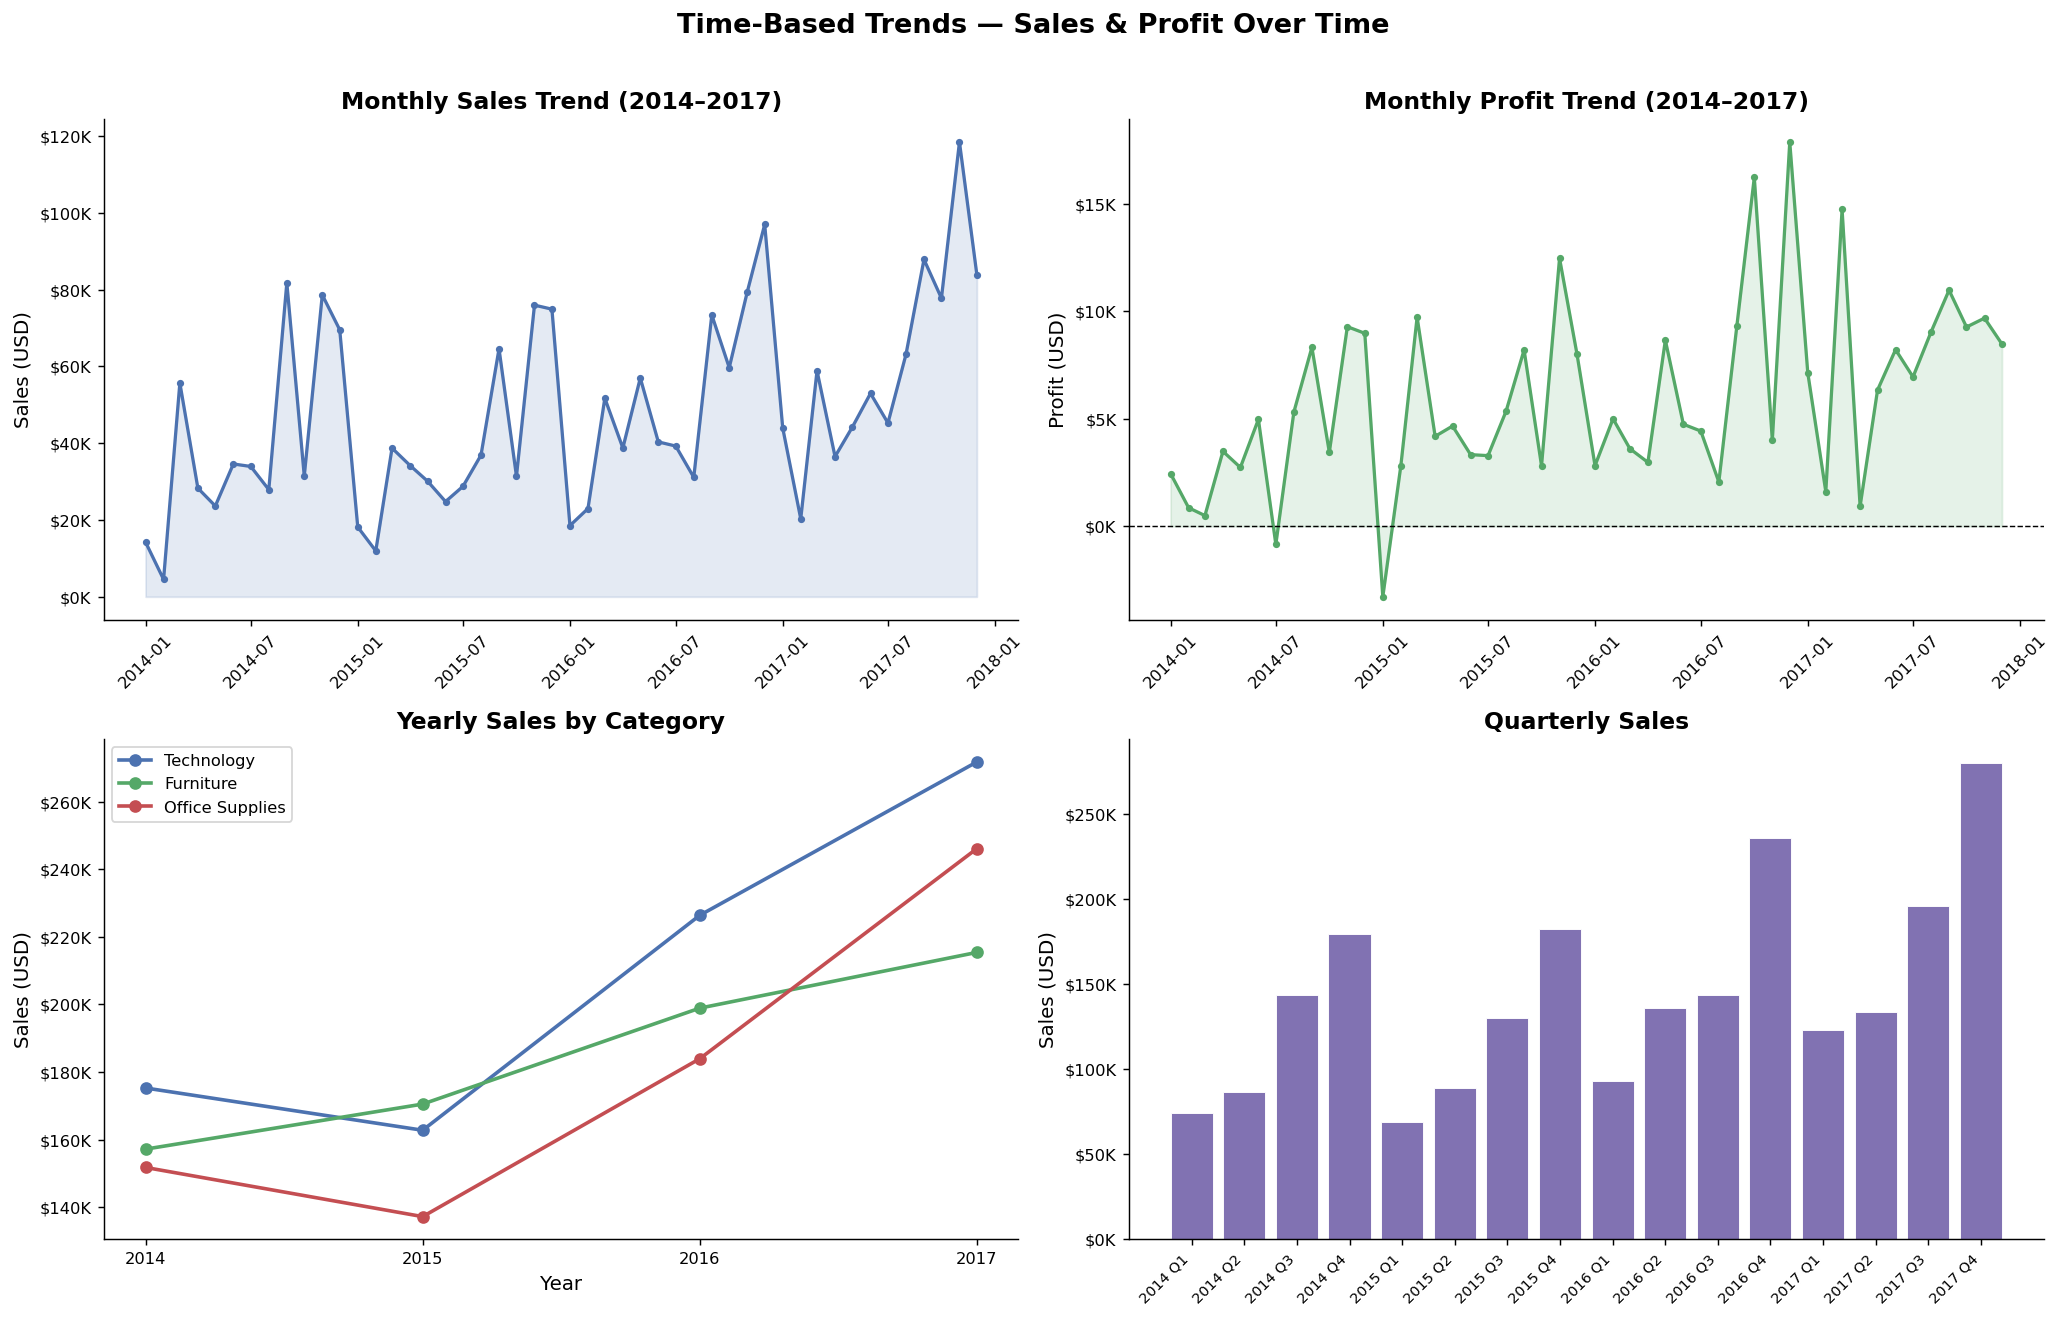

Saved: timeseries_analysis.png


In [14]:
# ─── TIME SERIES ANALYSIS ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Time-Based Trends — Sales & Profit Over Time",
             fontsize=15, fontweight="bold", y=1.01)

# 1. Monthly Sales Trend (all years combined)
monthly_sales = df.groupby(["Order Year", "Order Month"])["Sales"].sum().reset_index()
monthly_sales["Date"] = pd.to_datetime(monthly_sales[["Order Year", "Order Month"]].assign(day=1).rename(
    columns={"Order Year": "year", "Order Month": "month"}))
monthly_sales = monthly_sales.sort_values("Date")

axes[0,0].plot(monthly_sales["Date"], monthly_sales["Sales"],
               color="#4C72B0", linewidth=1.8, marker="o", markersize=3)
axes[0,0].fill_between(monthly_sales["Date"], monthly_sales["Sales"],
                        alpha=0.15, color="#4C72B0")
axes[0,0].set_title("Monthly Sales Trend (2014–2017)")
axes[0,0].set_ylabel("Sales (USD)")
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[0,0].tick_params(axis="x", rotation=45)

# 2. Monthly Profit Trend
monthly_profit = df.groupby(["Order Year", "Order Month"])["Profit"].sum().reset_index()
monthly_profit["Date"] = pd.to_datetime(monthly_profit[["Order Year", "Order Month"]].assign(day=1).rename(
    columns={"Order Year": "year", "Order Month": "month"}))
monthly_profit = monthly_profit.sort_values("Date")

axes[0,1].plot(monthly_profit["Date"], monthly_profit["Profit"],
               color="#55A868", linewidth=1.8, marker="o", markersize=3)
axes[0,1].fill_between(monthly_profit["Date"], monthly_profit["Profit"],
                        alpha=0.15, color="#55A868")
axes[0,1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0,1].set_title("Monthly Profit Trend (2014–2017)")
axes[0,1].set_ylabel("Profit (USD)")
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[0,1].tick_params(axis="x", rotation=45)

# 3. Yearly Sales by Category
yearly_cat = df.groupby(["Order Year", "Category"])["Sales"].sum().reset_index()
for cat, color in zip(["Technology", "Furniture", "Office Supplies"],
                       ["#4C72B0", "#55A868", "#C44E52"]):
    data = yearly_cat[yearly_cat["Category"] == cat]
    axes[1,0].plot(data["Order Year"], data["Sales"], marker="o",
                   label=cat, color=color, linewidth=2)
axes[1,0].set_title("Yearly Sales by Category")
axes[1,0].set_ylabel("Sales (USD)")
axes[1,0].set_xlabel("Year")
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[1,0].legend(fontsize=9)
axes[1,0].set_xticks([2014, 2015, 2016, 2017])

# 4. Quarterly Sales
quarterly = df.groupby(["Order Year", "Order Quarter"])["Sales"].sum().reset_index()
quarterly["YQ"] = quarterly["Order Year"].astype(str) + " Q" + quarterly["Order Quarter"].astype(str)
axes[1,1].bar(range(len(quarterly)), quarterly["Sales"],
              color="#8172B2", edgecolor="white", linewidth=0.5)
axes[1,1].set_title("Quarterly Sales")
axes[1,1].set_ylabel("Sales (USD)")
axes[1,1].set_xticks(range(len(quarterly)))
axes[1,1].set_xticklabels(quarterly["YQ"], rotation=45, ha="right", fontsize=8)
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))

plt.tight_layout()
plt.savefig("timeseries_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: timeseries_analysis.png")

## Correlation Heatmap and Discount Deep Dive

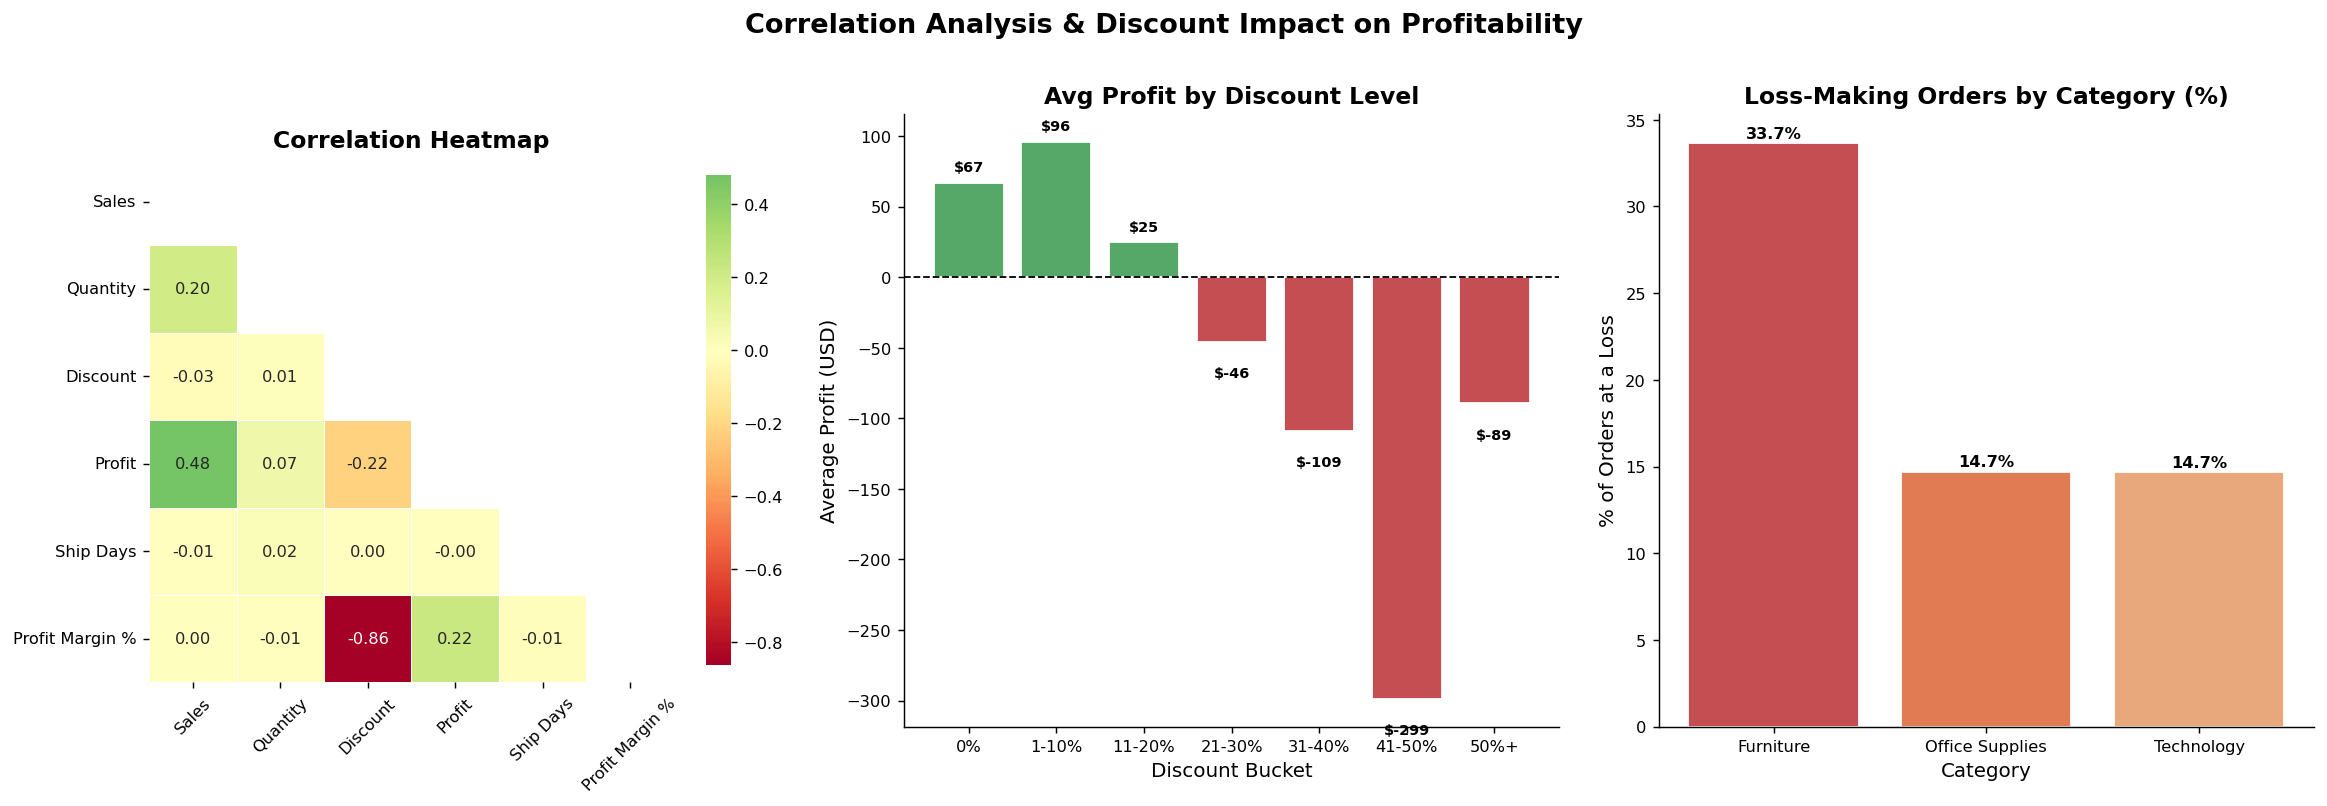

Saved: correlation_analysis.png

Key correlations with Profit:
Discount          -0.219487
Ship Days         -0.004649
Quantity           0.066253
Profit Margin %    0.223732
Sales              0.479064
Profit             1.000000
Name: Profit, dtype: float64


In [15]:
# ─── CORRELATION + DISCOUNT ANALYSIS ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Correlation Analysis & Discount Impact on Profitability",
             fontsize=15, fontweight="bold", y=1.01)

# 1. Correlation Heatmap
numeric_cols = ["Sales", "Quantity", "Discount", "Profit", 
                "Ship Days", "Profit Margin %"]
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            ax=axes[0],
            annot=True, 
            fmt=".2f",
            cmap="RdYlGn",
            center=0,
            mask=mask,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 9})
axes[0].set_title("Correlation Heatmap")
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

# 2. Average Profit by Discount Bucket
df["Discount Bucket"] = pd.cut(df["Discount"],
                                bins=[-0.01, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
                                labels=["0%","1-10%","11-20%","21-30%",
                                        "31-40%","41-50%","50%+"])
discount_profit = df.groupby("Discount Bucket", observed=True)["Profit"].mean()

colors_dp = ["#55A868" if v > 0 else "#C44E52" for v in discount_profit.values]
bars = axes[1].bar(discount_profit.index, discount_profit.values,
                   color=colors_dp, edgecolor="white")
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Avg Profit by Discount Level")
axes[1].set_xlabel("Discount Bucket")
axes[1].set_ylabel("Average Profit (USD)")
for bar, val in zip(bars, discount_profit.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (8 if val >= 0 else -25),
                 f"${val:.0f}", ha="center", fontsize=8, fontweight="bold")

# 3. Loss-making transactions by Category
loss_df = df[df["Profit"] < 0]
loss_by_cat = loss_df.groupby("Category").size().sort_values(ascending=False)
total_by_cat = df.groupby("Category").size()
loss_pct = (loss_by_cat / total_by_cat * 100).sort_values(ascending=False)

bars3 = axes[2].bar(loss_pct.index, loss_pct.values,
                    color=["#C44E52","#E07B54","#E8A87C"], edgecolor="white")
axes[2].set_title("Loss-Making Orders by Category (%)")
axes[2].set_xlabel("Category")
axes[2].set_ylabel("% of Orders at a Loss")
for bar, val in zip(bars3, loss_pct.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("correlation_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: correlation_analysis.png")

# ─── PRINT KEY CORRELATION VALUES ──────────────────────────────────────────
print("\nKey correlations with Profit:")
print(corr_matrix["Profit"].sort_values())

## Sub-category Deep Dive

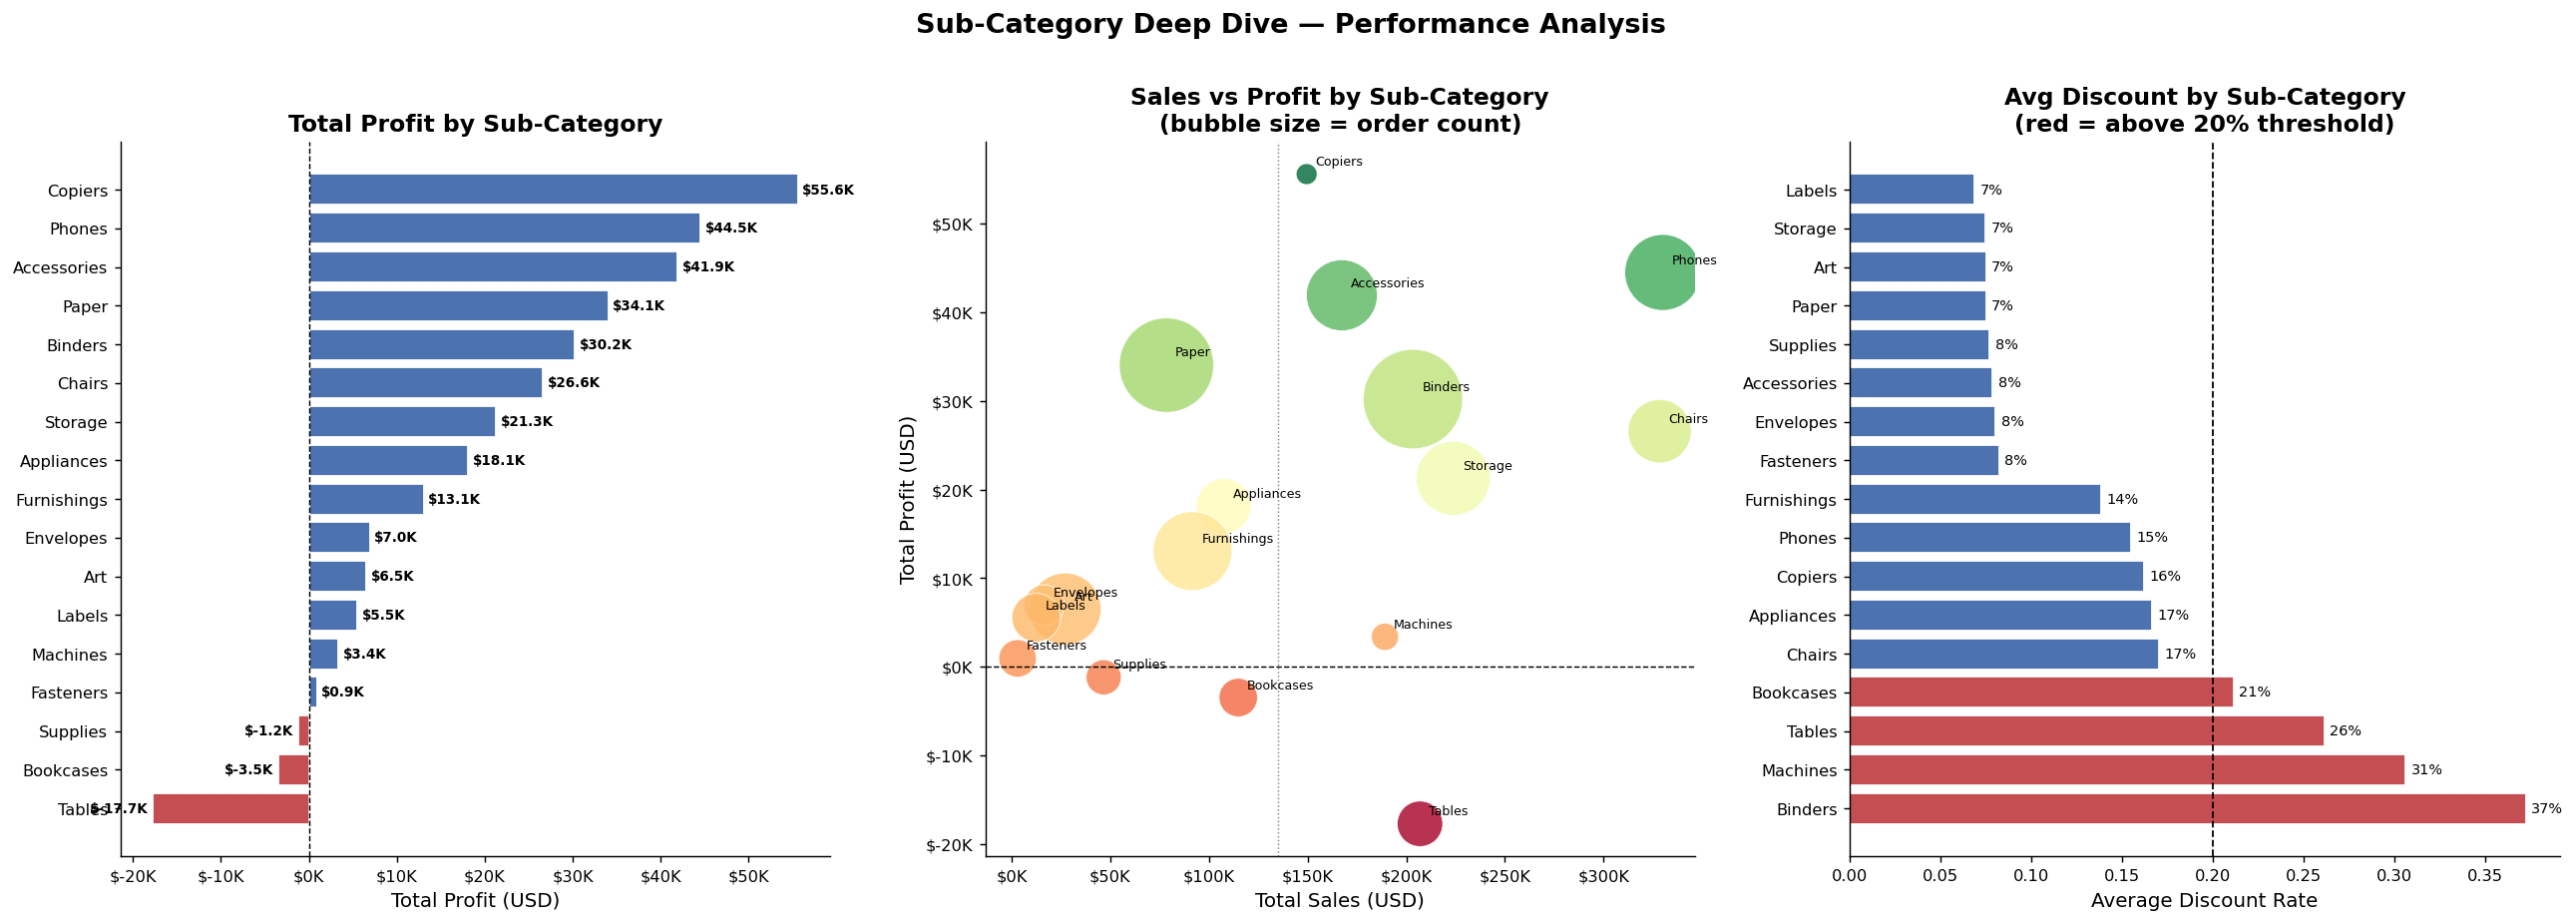

Saved: subcategory_analysis.png

Loss-making Sub-Categories:
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64


In [16]:
# ─── SUB-CATEGORY ANALYSIS ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Sub-Category Deep Dive — Performance Analysis",
             fontsize=15, fontweight="bold", y=1.01)

# 1. Profit by Sub-Category
subcat_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()
colors_sub = ["#C44E52" if v < 0 else "#4C72B0" for v in subcat_profit.values]

axes[0].barh(subcat_profit.index, subcat_profit.values,
             color=colors_sub, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Total Profit by Sub-Category")
axes[0].set_xlabel("Total Profit (USD)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
for i, (idx, val) in enumerate(subcat_profit.items()):
    axes[0].text(val + (500 if val >= 0 else -500),
                 i, f"${val/1e3:.1f}K",
                 va="center",
                 ha="left" if val >= 0 else "right",
                 fontsize=7.5, fontweight="bold")

# 2. Sales vs Profit Bubble Chart by Sub-Category
subcat_summary = df.groupby("Sub-Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "count")
).reset_index()

scatter = axes[1].scatter(subcat_summary["Sales"],
                          subcat_summary["Profit"],
                          s=subcat_summary["Orders"] * 2,
                          c=subcat_summary["Profit"],
                          cmap="RdYlGn",
                          alpha=0.8,
                          edgecolors="white",
                          linewidth=0.5)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].axvline(subcat_summary["Sales"].mean(), color="gray",
                linewidth=0.8, linestyle=":")
for _, row in subcat_summary.iterrows():
    axes[1].annotate(row["Sub-Category"],
                     (row["Sales"], row["Profit"]),
                     textcoords="offset points",
                     xytext=(5, 5),
                     fontsize=7)
axes[1].set_title("Sales vs Profit by Sub-Category\n(bubble size = order count)")
axes[1].set_xlabel("Total Sales (USD)")
axes[1].set_ylabel("Total Profit (USD)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))

# 3. Avg Discount by Sub-Category
subcat_discount = df.groupby("Sub-Category")["Discount"].mean().sort_values(ascending=False)
colors_disc = ["#C44E52" if v > 0.2 else "#4C72B0" for v in subcat_discount.values]
axes[2].barh(subcat_discount.index, subcat_discount.values,
             color=colors_disc, edgecolor="white")
axes[2].axvline(0.2, color="black", linewidth=1, linestyle="--")
axes[2].set_title("Avg Discount by Sub-Category\n(red = above 20% threshold)")
axes[2].set_xlabel("Average Discount Rate")
for i, (idx, val) in enumerate(subcat_discount.items()):
    axes[2].text(val + 0.003, i, f"{val:.0%}",
                 va="center", fontsize=8)

plt.tight_layout()
plt.savefig("subcategory_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: subcategory_analysis.png")

# ─── PRINT LOSS-MAKING SUB-CATEGORIES ──────────────────────────────────────
print("\nLoss-making Sub-Categories:")
print(subcat_profit[subcat_profit < 0].sort_values())

## Business Insight Summary

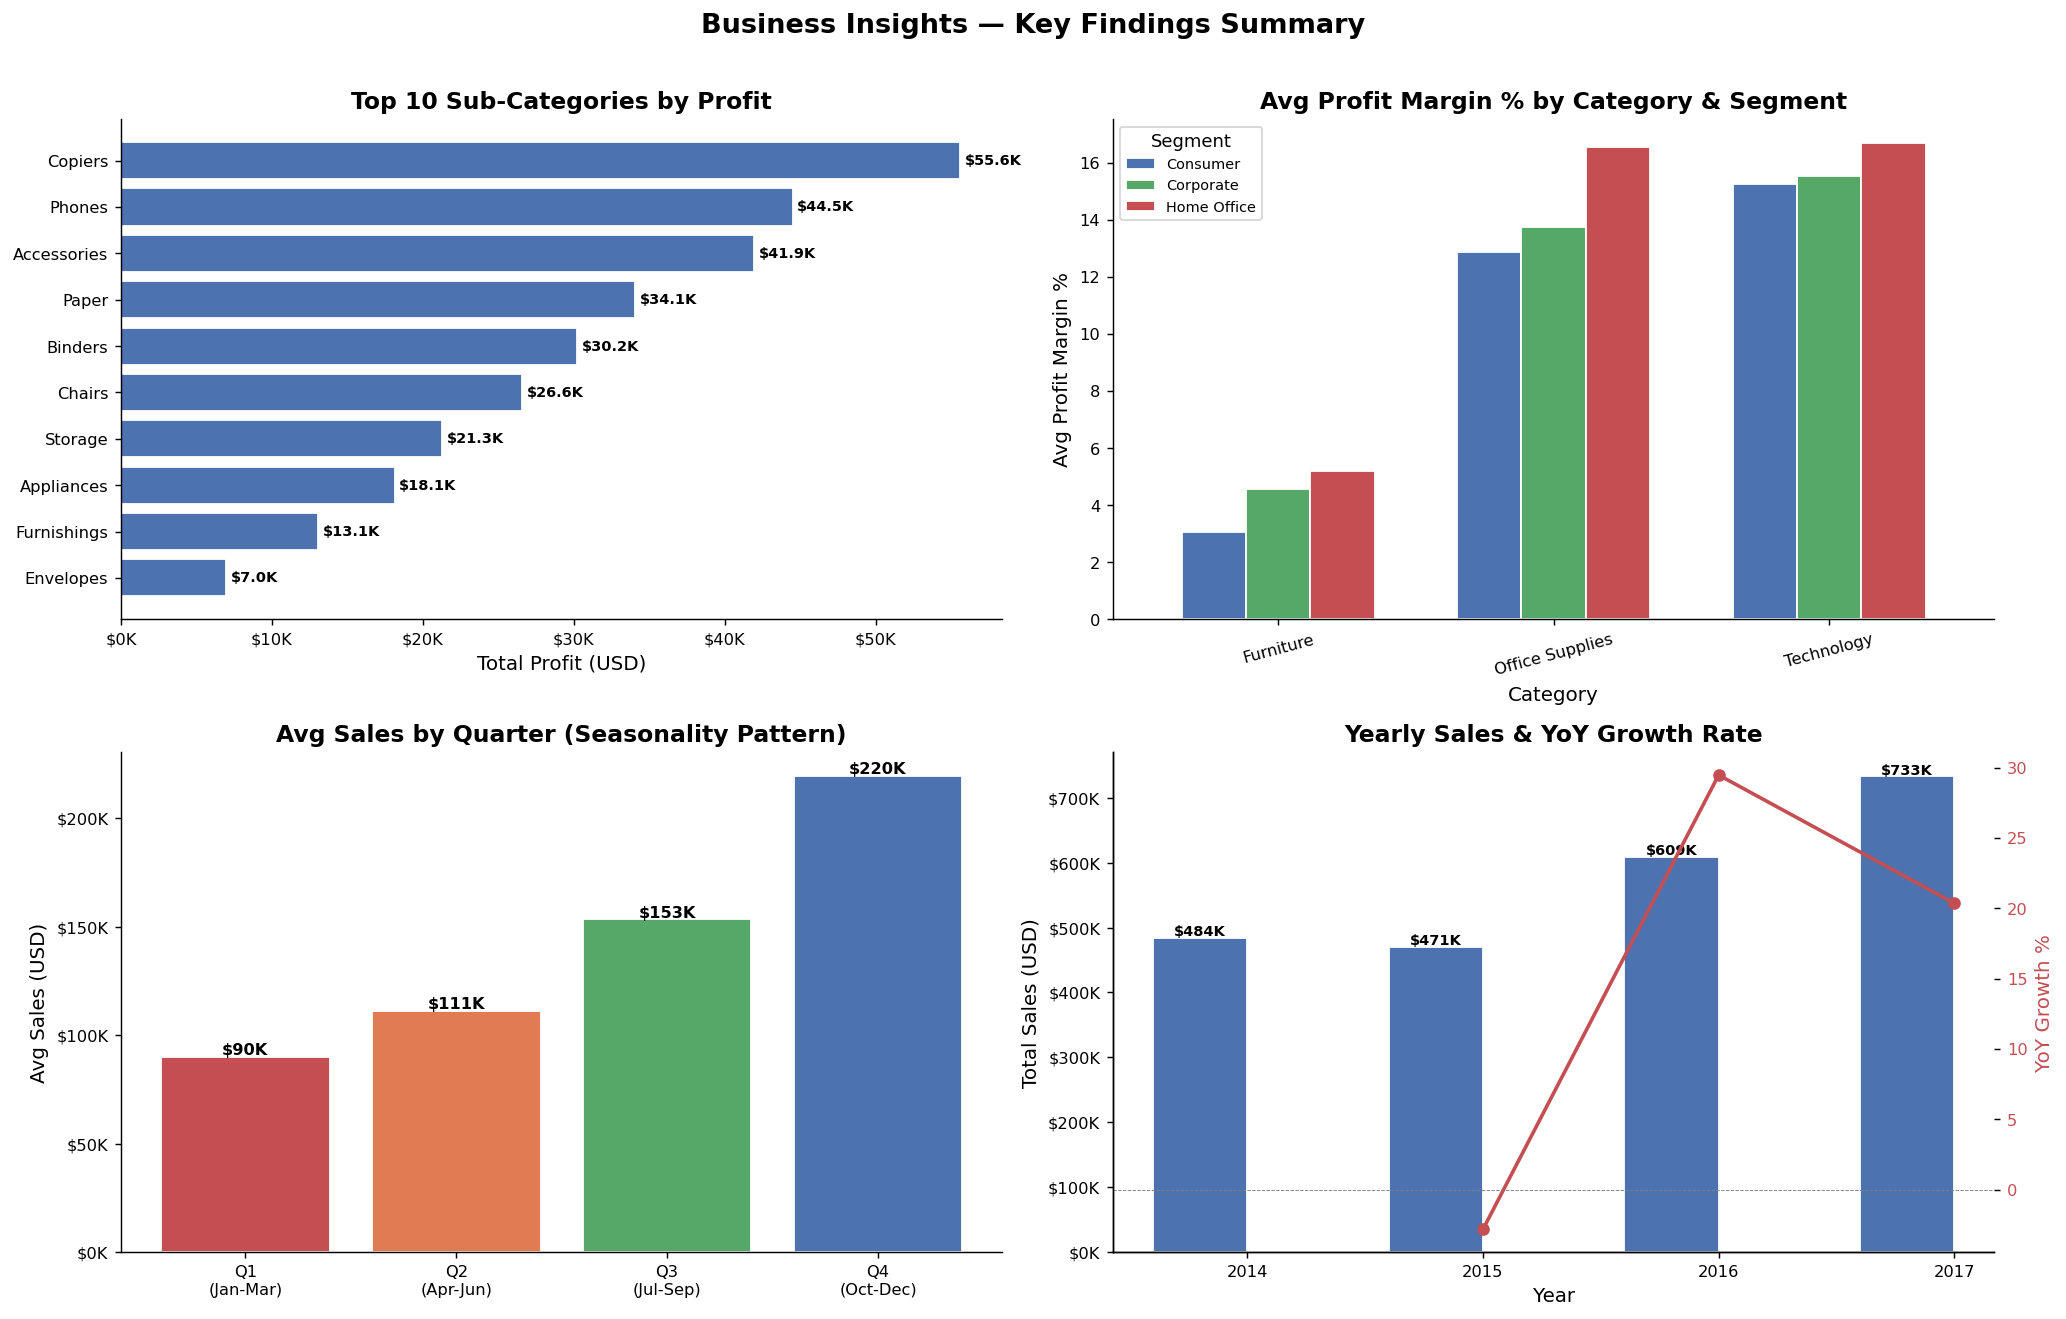

Saved: business_insights.png

EXECUTIVE SUMMARY — KEY METRICS
Total Revenue:        $   2,297,201
Total Profit:         $     286,397
Overall Profit Margin:        12.5%
Total Orders:                5,009
Loss-Making Orders:          1,871 (18.7%)
Avg Discount Applied:        15.6%
Avg Ship Days:                 4.0

Most Profitable Sub-Category: Copiers ($55,618)
Least Profitable Sub-Category: Tables ($-17,725)
Best Region by Profit: West ($108,418)
Worst Region by Profit: Central ($39,706)


In [17]:
# ─── BUSINESS INSIGHTS SUMMARY ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Business Insights — Key Findings Summary",
             fontsize=15, fontweight="bold", y=1.01)

# 1. Top 10 most profitable sub-categories
top10_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False).head(10)
axes[0,0].barh(top10_profit.index[::-1], top10_profit.values[::-1],
               color="#4C72B0", edgecolor="white")
axes[0,0].set_title("Top 10 Sub-Categories by Profit")
axes[0,0].set_xlabel("Total Profit (USD)")
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
for i, (idx, val) in enumerate(zip(top10_profit.index[::-1], top10_profit.values[::-1])):
    axes[0,0].text(val + 300, i, f"${val/1e3:.1f}K", va="center", fontsize=8, fontweight="bold")

# 2. Profit Margin % by Category and Segment
pivot = df.groupby(["Category", "Segment"])["Profit Margin %"].mean().unstack()
pivot.plot(kind="bar", ax=axes[0,1], color=["#4C72B0","#55A868","#C44E52"],
           edgecolor="white", width=0.7)
axes[0,1].set_title("Avg Profit Margin % by Category & Segment")
axes[0,1].set_xlabel("Category")
axes[0,1].set_ylabel("Avg Profit Margin %")
axes[0,1].legend(title="Segment", fontsize=8)
axes[0,1].tick_params(axis="x", rotation=15)

# 3. Monthly avg sales by quarter (seasonality)
quarterly_avg = df.groupby(["Order Year", "Order Quarter"])["Sales"].sum().groupby("Order Quarter").mean()
quarter_labels = ["Q1\n(Jan-Mar)", "Q2\n(Apr-Jun)", "Q3\n(Jul-Sep)", "Q4\n(Oct-Dec)"]
colors_q = ["#C44E52", "#E07B54", "#55A868", "#4C72B0"]
bars_q = axes[1,0].bar(quarter_labels, quarterly_avg.values,
                        color=colors_q, edgecolor="white")
axes[1,0].set_title("Avg Sales by Quarter (Seasonality Pattern)")
axes[1,0].set_ylabel("Avg Sales (USD)")
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
for bar, val in zip(bars_q, quarterly_avg.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                   f"${val/1e3:.0f}K", ha="center", fontsize=9, fontweight="bold")

# 4. YoY Revenue Growth
yearly_sales = df.groupby("Order Year")["Sales"].sum()
yoy_growth = yearly_sales.pct_change() * 100
x = np.arange(len(yearly_sales))
ax4 = axes[1,1]
bars_y = ax4.bar(x - 0.2, yearly_sales.values, width=0.4,
                  color="#4C72B0", edgecolor="white", label="Total Sales")
ax4_twin = ax4.twinx()
ax4_twin.plot(x, yoy_growth.values, color="#C44E52", marker="o",
              linewidth=2, markersize=6, label="YoY Growth %")
ax4_twin.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax4_twin.set_ylabel("YoY Growth %", color="#C44E52")
ax4_twin.tick_params(axis="y", labelcolor="#C44E52")
for i, (yr, val) in enumerate(yearly_sales.items()):
    ax4.text(i - 0.2, val + 3000, f"${val/1e3:.0f}K",
             ha="center", fontsize=8, fontweight="bold")
ax4.set_title("Yearly Sales & YoY Growth Rate")
ax4.set_xticks(x)
ax4.set_xticklabels(yearly_sales.index)
ax4.set_ylabel("Total Sales (USD)")
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax4.set_xlabel("Year")

plt.tight_layout()
plt.savefig("business_insights.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: business_insights.png")

# ─── PRINT SUMMARY STATS ───────────────────────────────────────────────────
print("\n" + "="*55)
print("EXECUTIVE SUMMARY — KEY METRICS")
print("="*55)
print(f"Total Revenue:        ${df['Sales'].sum():>12,.0f}")
print(f"Total Profit:         ${df['Profit'].sum():>12,.0f}")
print(f"Overall Profit Margin: {(df['Profit'].sum()/df['Sales'].sum()*100):>11.1f}%")
print(f"Total Orders:         {df['Order ID'].nunique():>12,}")
print(f"Loss-Making Orders:   {(df['Profit']<0).sum():>12,} ({(df['Profit']<0).mean()*100:.1f}%)")
print(f"Avg Discount Applied:  {df['Discount'].mean():>11.1%}")
print(f"Avg Ship Days:        {df['Ship Days'].mean():>12.1f}")
print("="*55)
print(f"\nMost Profitable Sub-Category: Copiers (${df[df['Sub-Category']=='Copiers']['Profit'].sum():,.0f})")
print(f"Least Profitable Sub-Category: Tables (${df[df['Sub-Category']=='Tables']['Profit'].sum():,.0f})")
print(f"Best Region by Profit: West (${df[df['Region']=='West']['Profit'].sum():,.0f})")
print(f"Worst Region by Profit: Central (${df[df['Region']=='Central']['Profit'].sum():,.0f})")